# Module 2 — Risk Engine

Multi-asset portfolio risk analysis:  
**VaR / CVaR** (historical + parametric), **PCA**, **Fama-French 3-factor regression**, **rolling VaR**.

In [2]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from portfolio import Portfolio, synthetic_portfolio, synthetic_ff_factors

np.random.seed(42)
print("OK")

OK


## 1. Portfolio construction

In [3]:
# synthetic_portfolio returns a pd.DataFrame with a DatetimeIndex — param is n_days (not n_obs)
returns = synthetic_portfolio(n_assets=5, n_days=500, seed=42)
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

port = Portfolio(returns, weights, name="QuantForge Portfolio")
pr   = port.portfolio_returns

print(port)
print(f"Date range : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets     : {port.assets}")

Portfolio('QuantForge Portfolio' | T=500, N=5 | ann_ret=-6.75%, ann_vol=13.18%)
Date range : 2019-01-01 -> 2020-11-30
Assets     : ['ASSET_1', 'ASSET_2', 'ASSET_3', 'ASSET_4', 'ASSET_5']


## 2. VaR & CVaR — historical vs parametric

In [4]:
# full_report() returns a RiskReport dataclass with all VaR/CVaR fields
report = port.full_report(confidence=0.95)
print(report)

print("\n--- Sensitivity table ---")
print(f"{'Confidence':>12} {'VaR hist (%)':>14} {'VaR param (%)':>14} {'CVaR hist (%)':>14}")
print("-" * 58)
for c in [0.90, 0.95, 0.99]:
    print(f"{c*100:>11.0f}%"
          f"  {port.var_historical(c)*100:>14.4f}"
          f"  {port.var_parametric(c)*100:>14.4f}"
          f"  {port.cvar_historical(c)*100:>14.4f}")


----------------------------------------------------
  QuantForge Portfolio  |  95%  |  1d
----------------------------------------------------
  Ann. Vol                  13.18 %
  Ann. Return               -6.75 %
  Observations                500
----------------------------------------------------
  VaR  Historical          1.4380 %
  VaR  Parametric          1.3926 %
  CVaR Historical          1.7534 %
  CVaR Parametric          1.7395 %
----------------------------------------------------

--- Sensitivity table ---
  Confidence   VaR hist (%)  VaR param (%)  CVaR hist (%)
----------------------------------------------------------
         90%          1.1360          1.0909          1.5214
         95%          1.4380          1.3926          1.7534
         99%          1.9672          1.9584          2.1597


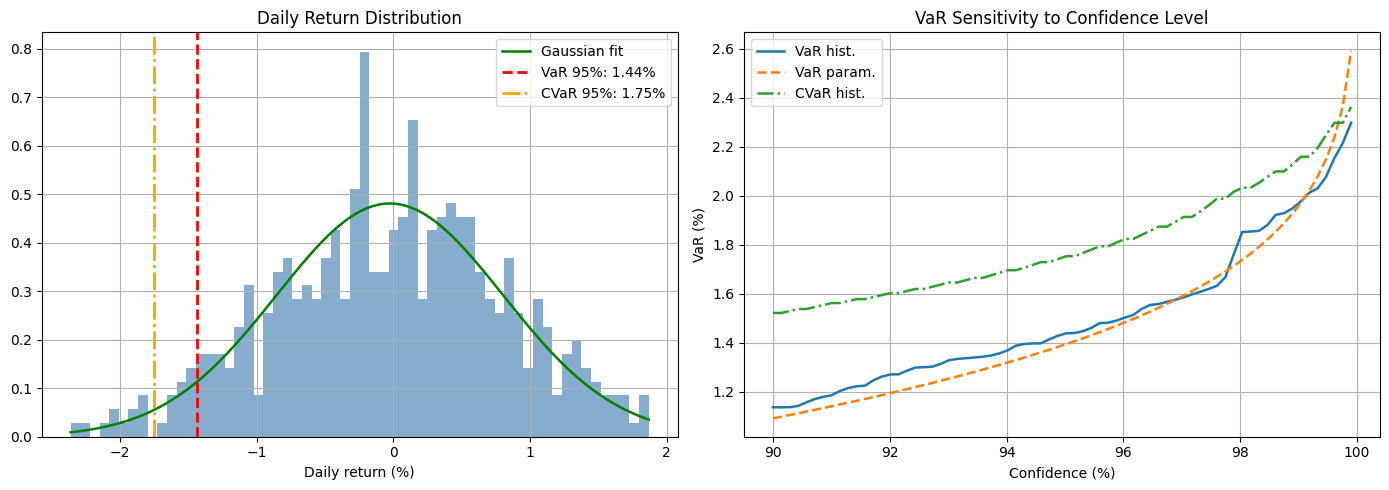

In [5]:
r_pct  = pr.values * 100
var_h  = -report.var_historical  * 100
cvar_h = -report.cvar_historical * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return distribution
ax = axes[0]
ax.hist(r_pct, bins=60, density=True, alpha=0.65, color="steelblue", edgecolor="none")
mu, sg = r_pct.mean(), r_pct.std()
xs = np.linspace(r_pct.min(), r_pct.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sg), color="green", lw=1.8, label="Gaussian fit")
ax.axvline(var_h,  color="red",    lw=2, ls="--", label=f"VaR 95%: {-var_h:.2f}%")
ax.axvline(cvar_h, color="orange", lw=2, ls="-.", label=f"CVaR 95%: {-cvar_h:.2f}%")
ax.set_title("Daily Return Distribution")
ax.set_xlabel("Daily return (%)"); ax.legend(); ax.grid(True)

# VaR sensitivity
ax2 = axes[1]
confs = np.linspace(0.90, 0.999, 70)
ax2.plot(confs*100, [port.var_historical(c)*100 for c in confs], lw=1.8, label="VaR hist.")
ax2.plot(confs*100, [port.var_parametric(c)*100  for c in confs], lw=1.8, ls="--", label="VaR param.")
ax2.plot(confs*100, [port.cvar_historical(c)*100 for c in confs], lw=1.8, ls="-.", label="CVaR hist.")
ax2.set_title("VaR Sensitivity to Confidence Level")
ax2.set_xlabel("Confidence (%)"); ax2.set_ylabel("VaR (%)")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

## 3. Principal Component Analysis (PCA)

In [6]:
# port.pca() returns a PCAResult dataclass
pca = port.pca()

print(pca.variance_table().to_string(index=False))
print(f"\nComponents for 90% variance: {pca.n_factors_for(0.90)}")

Component  Eigenvalue  Explained Var (%)  Cumulative Var (%)
      PC1    0.000471              50.17               50.17
      PC2    0.000269              28.62               78.79
      PC3    0.000133              14.21               93.00
      PC4    0.000037               3.94               96.94
      PC5    0.000029               3.06              100.00

Components for 90% variance: 3


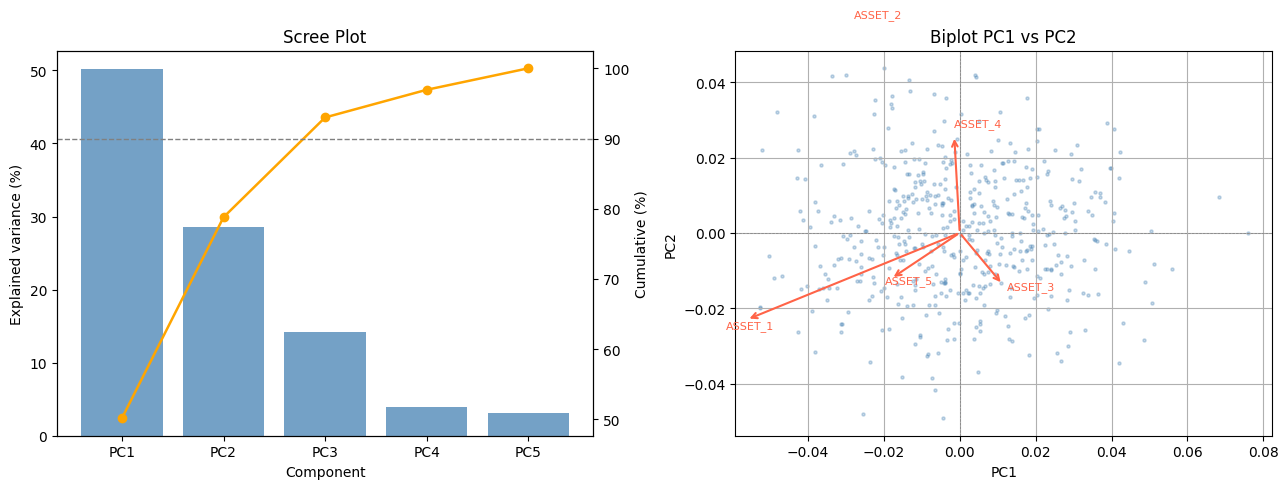

In [7]:
k   = len(pca.eigenvalues)
xs  = np.arange(1, k + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(xs, pca.explained_variance_ratio * 100, alpha=0.75, color="steelblue")
ax1b = axes[0].twinx()
ax1b.plot(xs, pca.cumulative_variance * 100, "o-", color="orange", lw=1.8)
ax1b.axhline(90, color="gray", lw=1, ls="--")
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f"PC{i}" for i in xs])
axes[0].set_title("Scree Plot")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Explained variance (%)")
ax1b.set_ylabel("Cumulative (%)")

# PC1 vs PC2 biplot
if pca.factor_returns.shape[1] >= 2:
    axes[1].scatter(pca.factor_returns["PC1"], pca.factor_returns["PC2"],
                    alpha=0.3, s=5, color="steelblue")
    scale = pca.factor_returns["PC1"].std() * 3
    for i, asset in enumerate(pca.asset_names):
        vx = pca.factor_loadings.iloc[i, 0] * scale
        vy = pca.factor_loadings.iloc[i, 1] * scale
        axes[1].annotate("", xy=(vx, vy), xytext=(0, 0),
                         arrowprops=dict(arrowstyle="->", color="tomato", lw=1.5))
        axes[1].text(vx * 1.1, vy * 1.1, asset, fontsize=8, color="tomato")
axes[1].axhline(0, color="gray", lw=0.5, ls="--")
axes[1].axvline(0, color="gray", lw=0.5, ls="--")
axes[1].set_title("Biplot PC1 vs PC2")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].grid(True)

plt.tight_layout(); plt.show()

## 4. Fama-French 3-factor regression

`synthetic_ff_factors(index, seed)` takes the portfolio **DatetimeIndex** and returns a DataFrame  
with columns `Mkt-RF`, `SMB`, `HML`, `RF`.  
`portfolio.fama_french(factors_df)` returns an `FFResult` — use `.summary()` to display.

In [8]:
ff_factors = synthetic_ff_factors(index=returns.index, seed=99)
ff = port.fama_french(ff_factors)

print(ff.summary().to_string())

         Alpha ann. (%)      R2  Sys. Vol (%)  Idio. Vol (%)  beta_Mkt-RF  beta_SMB  beta_HML
ASSET_1        -27.6780  0.0122        3.4948        31.4206      -0.1515    0.3092   -0.0596
ASSET_2          2.9222  0.0055        1.8612        25.0533       0.0600    0.1636   -0.1317
ASSET_3         -4.4106  0.0020        0.6834        15.4295       0.0295    0.0397   -0.0532
ASSET_4         -6.3367  0.0152        1.9396        15.6289       0.1167    0.0580   -0.0163
ASSET_5         -5.9856  0.0123        1.7507        15.6679      -0.1060   -0.0264   -0.0201


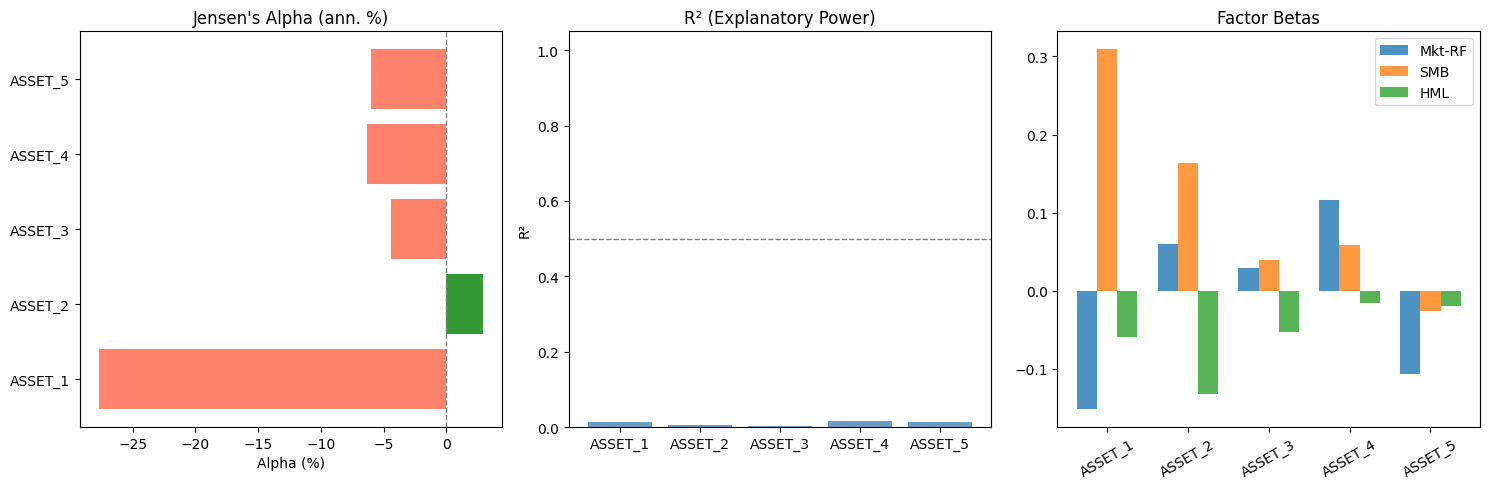

In [9]:
summary = ff.summary()
n = len(ff.asset_names)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Jensen's alpha
alphas = summary["Alpha ann. (%)"].values
axes[0].barh(ff.asset_names, alphas,
             color=["green" if a >= 0 else "tomato" for a in alphas], alpha=0.8)
axes[0].axvline(0, color="gray", lw=1, ls="--")
axes[0].set_title("Jensen's Alpha (ann. %)"); axes[0].set_xlabel("Alpha (%)")

# R-squared
axes[1].bar(ff.asset_names, summary["R2"].values, alpha=0.8, color="steelblue")
axes[1].axhline(0.5, color="gray", lw=1, ls="--"); axes[1].set_ylim(0, 1.05)
axes[1].set_title("R² (Explanatory Power)"); axes[1].set_ylabel("R²")

# Factor betas
betas = ff.betas
xp = np.arange(n); w = 0.25
axes[2].bar(xp - w, betas[:, 0], w, label="Mkt-RF", alpha=0.8)
axes[2].bar(xp,     betas[:, 1], w, label="SMB",    alpha=0.8)
axes[2].bar(xp + w, betas[:, 2], w, label="HML",    alpha=0.8)
axes[2].set_title("Factor Betas")
axes[2].set_xticks(xp); axes[2].set_xticklabels(ff.asset_names, rotation=30)
axes[2].legend()

plt.tight_layout(); plt.show()

## 5. Rolling VaR (60-day window)

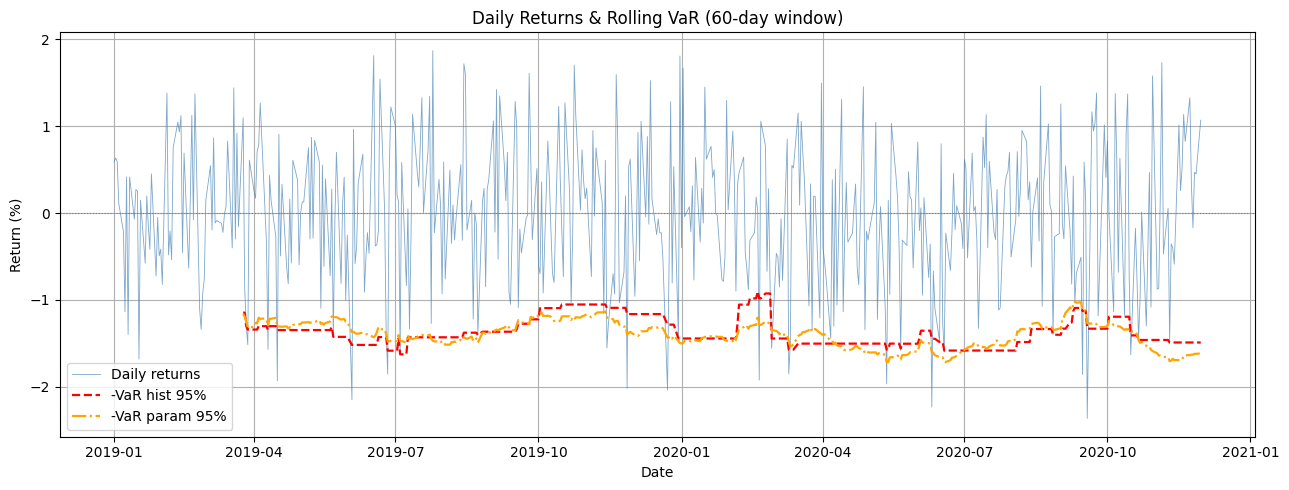

In [10]:
# rolling_var returns a pd.Series indexed by date
rv_hist  = port.rolling_var(confidence=0.95, window=60, parametric=False)
rv_param = port.rolling_var(confidence=0.95, window=60, parametric=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pr.index, pr.values * 100, color="steelblue", lw=0.6, alpha=0.7, label="Daily returns")
ax.plot(rv_hist.index,  -rv_hist.values  * 100, color="red",    lw=1.6, ls="--", label="-VaR hist 95%")
ax.plot(rv_param.index, -rv_param.values * 100, color="orange", lw=1.6, ls="-.", label="-VaR param 95%")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_title("Daily Returns & Rolling VaR (60-day window)")
ax.set_xlabel("Date"); ax.set_ylabel("Return (%)")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()